In [1]:
%autosave 30

Autosaving every 30 seconds


In [ ]:
import re
import typing as t

import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

from genpp.eval import best_models

sns.set_style("whitegrid")

# Energy spectrum along the zonal direction.

Given dataset with longitude dimension, this class computes spectral energy as a function of wavenumber (as a dim).  
Wavelength and frequency are also present as coords with units $1 / m$ and $m$ respectively. Only non-negative frequencies are included.  
  
Let $f[l]$, $l = 0, \ldots, L-1$, be dataset values along a zonal circle of constant
latitude, with circumference $C$ (m).

The discrete Fourier transform (DFT) is defined as
$$
F[k] = \frac{1}{L} \sum_{l=0}^{L-1} f[l]\,
\exp\!\left(-i\,\frac{2\pi k l}{L}\right).
$$

The energy spectrum is then defined as
$$
S[0] = C\,|F[0]|^2,
$$
$$
S[k] = 2C\,|F[k]|^2, \qquad k > 0,
$$
to account for contributions from both positive and negative frequencies.

Let $C_0$ be the equatorial circumference.  
The $i$-th zonal circle has circumference
$$
C(i) = C_0 \cos\!\left(\frac{\pi\,\text{latitude}[i]}{180}\right).
$$

Since data points occur at longitudes $\text{longitude}[l]$,
$l = 0, \ldots, L-1$, the DFT measures spectra at zonal sampling frequencies
$$
f(k,i) = \frac{\text{longitude}[k]}{C(i)\,360},
\qquad k = 0, \ldots, \left\lfloor \frac{L}{2} \right\rfloor,
$$
with corresponding wavelengths
$$
\lambda(k,i) = \frac{1}{f(k,i)}.
$$

This choice of normalization ensures that Parseval’s relation for energy holds.
Suppose $f[l]$ are sampled values of a continuous function $f(\ell)$,
where $0 < \ell < C$ (meters) is a coordinate on the circle.
The longitudinal sample spacing is $C/L$, hence
$$
\int_0^C |f(\ell)|^2 \, d\ell
\;\approx\;
\frac{C}{L} \sum_{l=0}^{L-1} |f[l]|^2
\;=\;
\sum_k S[k].
$$

If $f$ has units $\beta$, then $S$ has units $\mathrm{m}\,\beta^2$.
For example, if $f$ is the zonal wind component
$u$ with units $\mathrm{m\,s^{-1}}$, then
$$
[S] = \mathrm{m^3\,s^{-2}}.
$$

In air with mass density $ \rho $ ($ \mathrm{kg\,m^{-3}} $),
the energy density at wavenumber $ k $ is
$$
\rho\,S[k]
\;\sim\;
(\mathrm{kg\,m^{-3}})\,(\mathrm{m^3\,s^{-2}})
\;=\;
\mathrm{kg\,s^{-2}},
$$
which corresponds to an energy density per unit area.



## Problems on our limited Domain
- Longitude dimension doesn't wrap around the globe (not periodic) -> this will lead to spurious edge effects
- Limited resolution -> 37 // 2 + 1 = only 19 wavenumbers

In [9]:
EARTH_RADIUS_M = 6_371_000  # meters


def _circumference(dataset: xr.Dataset) -> xr.DataArray:
    """Earth's circumference as a function of latitude."""
    circum_at_equator = 2 * np.pi * EARTH_RADIUS_M
    return np.cos(dataset.latitude * np.pi / 180) * circum_at_equator


def lon_spacing_m(dataset: xr.Dataset) -> xr.DataArray:
    """Spacing (meters) between longitudinal values in `dataset`."""
    diffs = dataset.longitude.diff("longitude")
    if np.max(np.abs(diffs - diffs[0])) > 1e-3:
        raise ValueError(f"Expected uniform longitude spacing. {dataset.longitude.values=}")
    return _circumference(dataset) * diffs[0].data / 360


def compute(dataset: xr.Dataset, feature: str) -> xr.DataArray:
    """Computes zonal power at wavenumber and frequency."""
    spacing = lon_spacing_m(dataset)

    def simple_power(f_x):
        f_k = np.fft.rfft(f_x, axis=-1, norm="forward")
        # freq > 0 should be counted twice in power since it accounts for both
        # positive and negative complex values.
        one_and_many_twos = np.concatenate(([1], [2] * (f_k.shape[-1] - 1)))
        return np.real(f_k * np.conj(f_k)) * one_and_many_twos

    spectrum = xr.apply_ufunc(
        simple_power,
        dataset,
        input_core_dims=[["longitude"]],
        output_core_dims=[["longitude"]],
        exclude_dims={"longitude"},
    ).rename_dims({"longitude": "zonal_wavenumber"})[feature]
    spectrum = spectrum.assign_coords(
        zonal_wavenumber=("zonal_wavenumber", spectrum.zonal_wavenumber.data)
    )
    base_frequency = xr.DataArray(
        np.fft.rfftfreq(len(dataset.longitude)),
        dims="zonal_wavenumber",
        coords={"zonal_wavenumber": spectrum.zonal_wavenumber},
    )
    spectrum = spectrum.assign_coords(frequency=base_frequency / spacing)
    spectrum["frequency"] = spectrum.frequency.assign_attrs(units="1 / m")

    spectrum = spectrum.assign_coords(wavelength=1 / spectrum.frequency)
    spectrum["wavelength"] = spectrum.wavelength.assign_attrs(units="m")

    # This last step ensures the sum of spectral components is equal to the
    # (discrete) integral of data around a line of latitude.
    return spectrum * _circumference(spectrum)


def interpolate_spectral_frequencies(
    spectrum: xr.DataArray,
    wavenumber_dim: str = "zonal_wavenumber",
    frequencies: t.Optional[t.Sequence[float]] = None,
    method: str = "linear",
    **interp_kwargs: t.Optional[dict[str, t.Any]],
) -> xr.DataArray:
    """Interpolate frequencies in `spectrum` to common values.

    Args:
      spectrum: Data as produced by ZonalEnergySpectrum.compute.
      wavenumber_dim: Dimension that indexes wavenumber, e.g. 'zonal_wavenumber'
        if `spectrum` is produced by ZonalEnergySpectrum.
      frequencies: Optional 1-D sequence of frequencies to interpolate to. By
        default, use the most narrow range of frequencies in `spectrum`.
      method: Interpolation method passed on to DataArray.interp.
      **interp_kwargs: Additional kwargs passed on to DataArray.interp.

    Returns:
      New DataArray with dimension "frequency" replacing the "wavenumber" dim in
        `spectrum`.
    """

    if set(spectrum.frequency.dims) != set((wavenumber_dim, "latitude")):
        raise ValueError(
            f'{spectrum.frequency.dims=} was not a permutation of ("{wavenumber_dim}", "latitude")'
        )

    if frequencies is None:
        freq_min = spectrum.frequency.max("latitude").min(wavenumber_dim).data
        freq_max = spectrum.frequency.min("latitude").max(wavenumber_dim).data
        frequencies = np.linspace(freq_min, freq_max, num=spectrum.sizes[wavenumber_dim])
    frequencies = np.asarray(frequencies)  # type: ignore
    if frequencies.ndim != 1:  # type: ignore
        raise ValueError(f"Expected 1-D frequencies, found {frequencies.shape=}")  # type: ignore

    def interp_at_one_lat(da: xr.DataArray) -> xr.DataArray:
        da = (
            da.squeeze("latitude")
            .swap_dims({wavenumber_dim: "frequency"})  # pytype: disable=wrong-arg-types
            .drop_vars(wavenumber_dim)
            .interp(frequency=frequencies, method=method, **interp_kwargs)  # type: ignore
        )
        # Interp didn't deal well with the infinite wavelength, so just reset λ as..
        da["wavelength"] = 1 / da.frequency
        da["wavelength"] = da["wavelength"].assign_attrs(units="m")
        return da

    return spectrum.groupby("latitude", squeeze=False).apply(interp_at_one_lat)

In [ ]:
for model_architecture, s in best_models:
    for s1 in s:
        print(s1.tag)

None
None
standard
chen_spatial_3
chen_spatial_5
chen_spatial_7
unet_std
unet_abs
uvit_std
uvit_abs
standard


In [ ]:
_re = re.compile(r"predictions(?:_(?P<variant>.+))?$")
res = []
for model_architecture, sample_model_list in best_models:
    for sample_model in sample_model_list:
        sample_preds_paths = list(sample_model.model_dir.rglob("*.zarr"))
        full_name = (
            model_architecture + "_" + sample_model.tag if sample_model.tag else model_architecture
        )
        for sample_preds_path in sample_preds_paths:
            m = _re.search(sample_preds_path.stem)
            suffix = m.group("variant") if m and m.group("variant") else None
            if suffix:
                full_name += f"_{suffix}"
            print(f"Processing predictions from model: {full_name}")
            sample_preds = xr.open_zarr(sample_preds_path)
            # In the rest of this notebook we want to work with a Dataset rather than a DataArray
            sample_preds = sample_preds.rename_vars({"__xarray_dataarray_variable__": "data"})
            sample_preds = sample_preds["data"].to_dataset(dim="feature")
            zonal_power = compute(sample_preds.load(), feature="2m_temperature")
            spectrum = interpolate_spectral_frequencies(zonal_power)

            spectrum_mean = (
                spectrum.mean(dim=["latitude", "sample"]).groupby("prediction_timedelta").mean()
            )
            spectrum_mean_pd: pd.DataFrame = spectrum_mean.swap_dims(
                {"frequency": "wavelength"}
            ).to_pandas()  # type: ignore
            spectrum_mean_pd = spectrum_mean_pd.reset_index("prediction_timedelta").melt(
                id_vars="prediction_timedelta", value_name="power"
            )
            spectrum_mean_pd["model"] = full_name
            res.append(spectrum_mean_pd)

Processing predictions from model: emos_gca
Processing predictions from model: emos_gca_ecc
Processing predictions from model: drn_gca
Processing predictions from model: drn_gca_ecc
Processing predictions from model: chen_standard
Processing predictions from model: chen_chen_spatial_3
Processing predictions from model: chen_chen_spatial_5
Processing predictions from model: chen_chen_spatial_7
Processing predictions from model: fm_unet_std
Processing predictions from model: fm_unet_abs
Processing predictions from model: fm_uvit_std
Processing predictions from model: fm_uvit_abs
Processing predictions from model: engression_standard


In [ ]:
# Add HRES forecasts to the plot
from genpp.data import FC_VARS, VAL_PREDICTIONS
from genpp.data import FORECAST_ENS_PATH as FEP

fc = (
    xr.open_zarr(FEP)[FC_VARS]
    .stack(prediction=["time", "prediction_timedelta"])
    .sel(prediction=VAL_PREDICTIONS)
)

zonal_power = compute(fc.load(), feature="2m_temperature")
spectrum = interpolate_spectral_frequencies(zonal_power)

spectrum_mean = spectrum.mean(dim=["latitude", "number"]).groupby("prediction_timedelta").mean()
spectrum_mean_pd: pd.DataFrame = spectrum_mean.swap_dims({"frequency": "wavelength"}).to_pandas()  # type: ignore
spectrum_mean_pd = spectrum_mean_pd.reset_index("prediction_timedelta").melt(
    id_vars="prediction_timedelta", value_name="power"
)
spectrum_mean_pd["model"] = "IFS-ENS"
res.append(spectrum_mean_pd)
spectrum_mean_all = pd.concat(res)

In [128]:
spectrum_mean_all["model"] = spectrum_mean_all["model"].astype("string")
spectrum_mean_all["wavelength"] = spectrum_mean_all["wavelength"].astype("float64")

In [132]:
spectrum_mean_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1330 entries, 0 to 94
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   prediction_timedelta  1330 non-null   timedelta64[ns]
 1   wavelength            1330 non-null   float64        
 2   power                 1330 non-null   float64        
 3   model                 1330 non-null   string         
dtypes: float64(2), string(1), timedelta64[ns](1)
memory usage: 52.0 KB


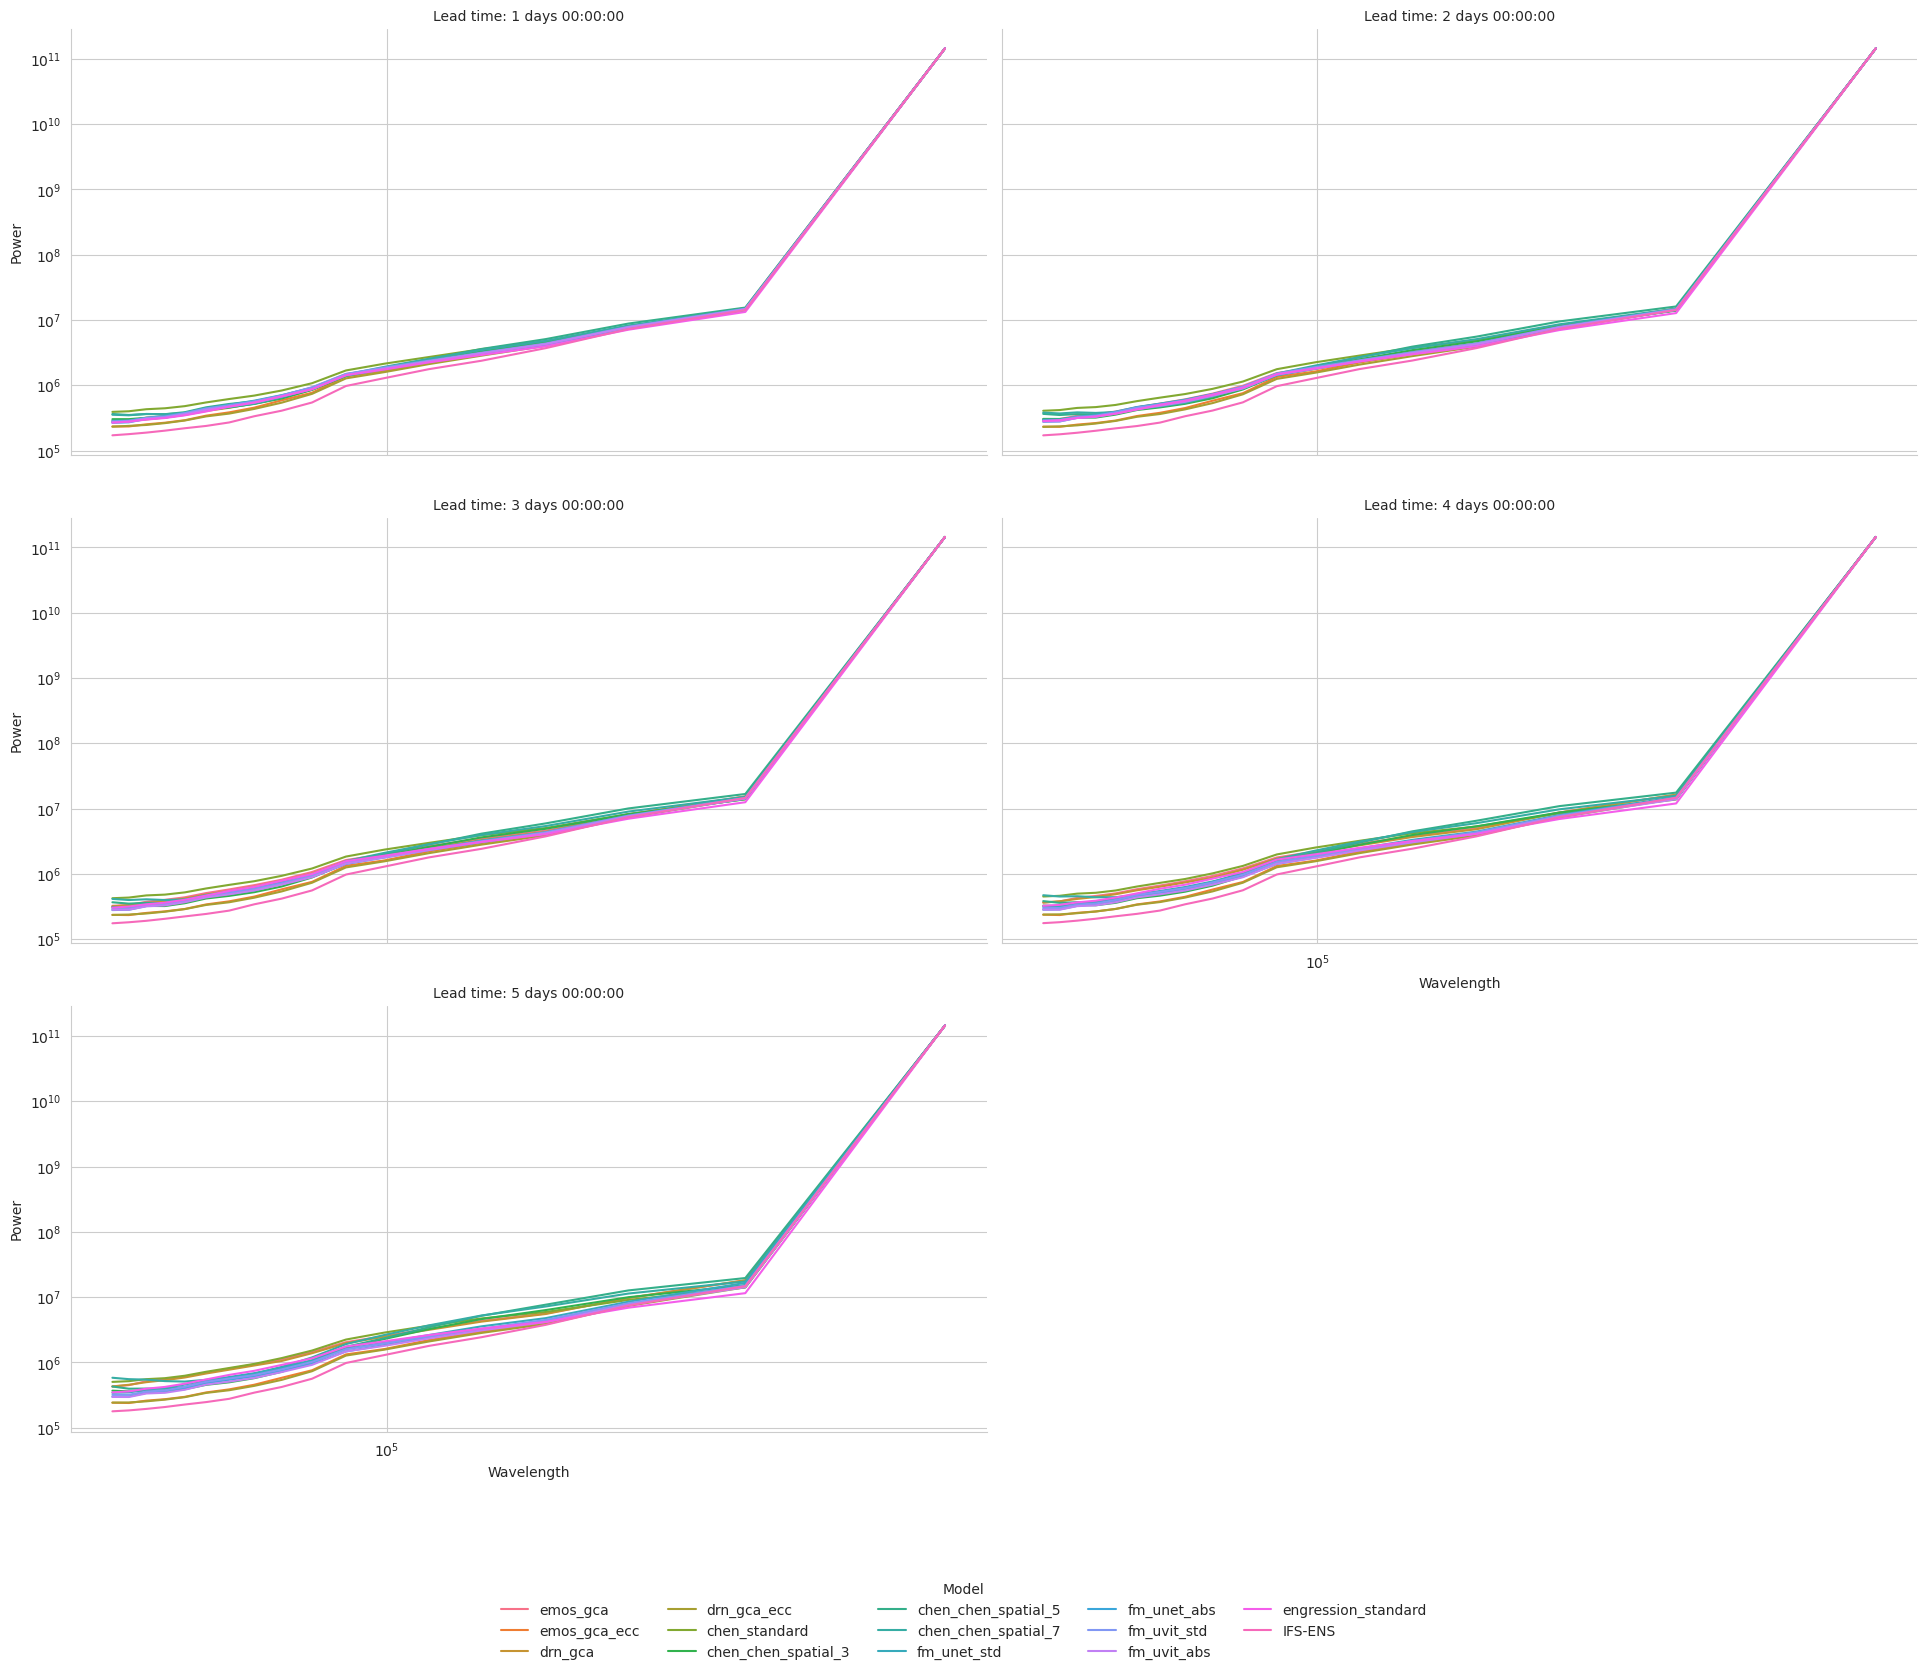

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.FacetGrid(
    spectrum_mean_all,
    col="prediction_timedelta",
    col_wrap=2,  # adjust depending on how many lead times you have
    hue="model",
    sharex=True,
    sharey=True,
    height=5,
)

g.map_dataframe(sns.lineplot, x="wavelength", y="power")

for ax in g.axes.flatten():
    ax.set_yscale("log")
    ax.set_xscale("log")

g.add_legend(
    title="Model",
    bbox_to_anchor=(0.5, -0.05),  # centered below
    loc="upper center",
    ncol=5,
)
g.set_axis_labels("Wavelength", "Power")
g.set_titles(col_template="Lead time: {col_name}")

plt.tight_layout()
plt.show()

# 2D Discrete Fourier Transform